In [1]:
import pandas as pd
import numpy as np
import scipy.stats as stats
from sklearn.model_selection import train_test_split
import xgboost as xgb
import shap

print("All libraries imported successfully")

All libraries imported successfully


In [2]:
df = pd.read_csv('../data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [4]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [5]:
df.isnull().sum()


customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [6]:
df['Churn'].value_counts(normalize=True)

Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64

In [7]:
df.shape

(7043, 21)

In [8]:

df[df['TotalCharges'] == ' ']

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,,No


In [9]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [10]:
df['TotalCharges'].isnull().sum()

np.int64(11)

In [11]:
df['TotalCharges'] = df['TotalCharges'].fillna(0)

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [13]:
df.duplicated().sum()

np.int64(0)

In [14]:
df.groupby('Contract')['Churn'].value_counts(normalize=True).unstack()

Churn,No,Yes
Contract,,
Month-to-month,0.572903,0.427097
One year,0.887305,0.112695
Two year,0.971681,0.028319


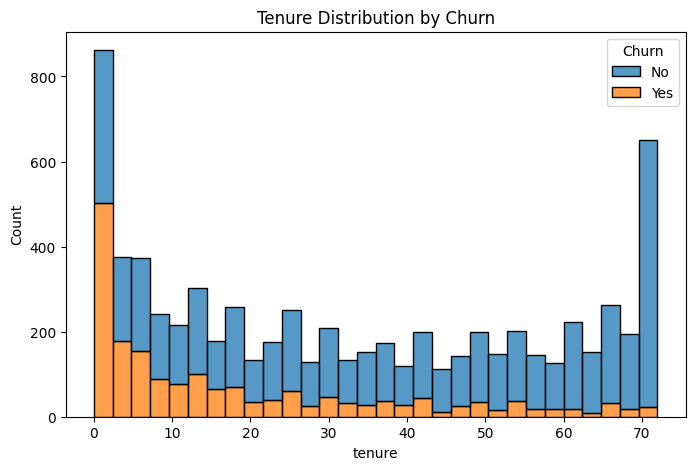

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.histplot(data=df, x='tenure', hue='Churn', bins=30, multiple='stack')
plt.title('Tenure Distribution by Churn')
plt.show()

In [16]:
from scipy.stats import chi2_contingency

contingency = pd.crosstab(df['Contract'], df['Churn'])
chi2, p, dof, expected = chi2_contingency(contingency)
print(f"Chi-square: {chi2:.2f}, p-value: {p:.5f}")

Chi-square: 1184.60, p-value: 0.00000


In [17]:
from scipy.stats import ttest_ind

churned = df[df['Churn'] == 'Yes']['tenure']
retained = df[df['Churn'] == 'No']['tenure']

t_stat, p_val = ttest_ind(churned, retained)
print(f"T-statistic: {t_stat:.2f}, p-value: {p_val:.5f}")

T-statistic: -31.58, p-value: 0.00000


In [18]:
for col in ['PaymentMethod', 'InternetService', 'PaperlessBilling']:
    contingency = pd.crosstab(df[col], df['Churn'])
    chi2, p, dof, expected = chi2_contingency(contingency)
    print(f"{col}: chi2={chi2:.2f}, p-value={p:.5f}")

PaymentMethod: chi2=648.14, p-value=0.00000
InternetService: chi2=732.31, p-value=0.00000
PaperlessBilling: chi2=258.28, p-value=0.00000


In [19]:
df.groupby('PaymentMethod')['Churn'].value_counts(normalize=True).unstack()

Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),0.832902,0.167098
Credit card (automatic),0.847569,0.152431
Electronic check,0.547146,0.452854
Mailed check,0.808933,0.191067


In [20]:
def tenure_bucket(t):
    if t <= 6:
        return '0-6mo'
    elif t <= 12:
        return '6-12mo'
    elif t <= 24:
        return '1-2yr'
    else:
        return '2yr+'

df['tenure_bucket'] = df['tenure'].apply(tenure_bucket)

In [21]:
addon_cols = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 
              'TechSupport', 'StreamingTV', 'StreamingMovies']

df['services_count'] = (df[addon_cols] == 'Yes').sum(axis=1)
df['adoption_score'] = df['services_count'] / len(addon_cols)

In [22]:
df['Churn_binary'] = (df['Churn'] == 'Yes').astype(int)

In [23]:
categorical_cols = df.select_dtypes(include='object').columns.tolist()
categorical_cols.remove('Churn')  # keep original for reference

df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

In [24]:
df_encoded.shape
df_encoded.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,services_count,adoption_score,Churn_binary,customerID_0003-MKNFE,customerID_0004-TLHLJ,...,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,tenure_bucket_1-2yr,tenure_bucket_2yr+,tenure_bucket_6-12mo
0,0,1,29.85,29.85,No,1,0.166667,0,False,False,...,False,False,False,True,False,True,False,False,False,False
1,0,34,56.95,1889.50,No,2,0.333333,0,False,False,...,False,True,False,False,False,False,True,False,True,False
2,0,2,53.85,108.15,Yes,2,0.333333,1,False,False,...,False,False,False,True,False,False,True,False,False,False
3,0,45,42.30,1840.75,No,3,0.500000,0,False,False,...,False,True,False,False,False,False,False,False,True,False
4,0,2,70.70,151.65,Yes,0,0.000000,1,False,False,...,False,False,False,True,False,True,False,False,False,False


In [25]:
# Save customerID separately first (you'll need it later for Power BI drill-through)
customer_ids = df['customerID'].copy()

# Drop it from the working dataframe
df = df.drop('customerID', axis=1)

# Now redo the categorical encoding
categorical_cols = df.select_dtypes(include='object').columns.tolist()
categorical_cols.remove('Churn')  # keep original Churn column for reference

df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# Check shape again
df_encoded.shape


(7043, 37)

In [26]:
df_encoded.shape

(7043, 37)

In [27]:
# Drop the original string Churn column, keep only the binary target
X = df_encoded.drop(['Churn', 'Churn_binary'], axis=1)
y = df_encoded['Churn_binary']

X.shape, y.shape

((7043, 35), (7043,))

In [28]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train.shape, X_test.shape

((5634, 35), (1409, 35))

In [29]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

# Scale features (LogReg is sensitive to feature scale)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

logreg = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
logreg.fit(X_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [30]:
from sklearn.metrics import classification_report, roc_auc_score

y_pred = logreg.predict(X_test_scaled)
y_proba = logreg.predict_proba(X_test_scaled)[:, 1]

print(classification_report(y_test, y_pred))
print(f"AUC-ROC: {roc_auc_score(y_test, y_proba):.4f}")

              precision    recall  f1-score   support

           0       0.91      0.72      0.80      1035
           1       0.51      0.80      0.62       374

    accuracy                           0.74      1409
   macro avg       0.71      0.76      0.71      1409
weighted avg       0.80      0.74      0.75      1409

AUC-ROC: 0.8448


In [31]:
import xgboost as xgb

# Calculate scale_pos_weight for imbalance (ratio of negative to positive class)
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

xgb_model = xgb.XGBClassifier(
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric='logloss'
)

xgb_model.fit(X_train, y_train)  # XGBoost doesn't need scaled features

y_pred_xgb = xgb_model.predict(X_test)
y_proba_xgb = xgb_model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred_xgb))
print(f"AUC-ROC: {roc_auc_score(y_test, y_proba_xgb):.4f}")

              precision    recall  f1-score   support

           0       0.86      0.79      0.83      1035
           1       0.53      0.65      0.59       374

    accuracy                           0.76      1409
   macro avg       0.70      0.72      0.71      1409
weighted avg       0.78      0.76      0.76      1409

AUC-ROC: 0.8160


In [32]:
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    'max_depth': [3, 4, 5, 6],
    'learning_rate': [0.01, 0.05, 0.1],
    'n_estimators': [100, 200, 300],
    'subsample': [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0]
}

xgb_search = RandomizedSearchCV(
    xgb.XGBClassifier(scale_pos_weight=scale_pos_weight, random_state=42, eval_metric='logloss'),
    param_distributions=param_dist,
    n_iter=20,
    scoring='roc_auc',
    cv=3,
    random_state=42,
    n_jobs=-1
)

xgb_search.fit(X_train, y_train)
print("Best params:", xgb_search.best_params_)

best_xgb = xgb_search.best_estimator_
y_pred_best = best_xgb.predict(X_test)
y_proba_best = best_xgb.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred_best))
print(f"AUC-ROC: {roc_auc_score(y_test, y_proba_best):.4f}")

C:\Users\hp\Desktop\churn-analytics\venv\lib\site-packages\sklearn\model_selection\_search.py:1135: UserWarning: One or more of the test scores are non-finite: [nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan]
  warnings.warn(


Best params: {'subsample': 0.7, 'n_estimators': 300, 'max_depth': 5, 'learning_rate': 0.01, 'colsample_bytree': 0.8}
              precision    recall  f1-score   support

           0       0.91      0.74      0.81      1035
           1       0.52      0.80      0.63       374

    accuracy                           0.75      1409
   macro avg       0.72      0.77      0.72      1409
weighted avg       0.81      0.75      0.77      1409

AUC-ROC: 0.8469


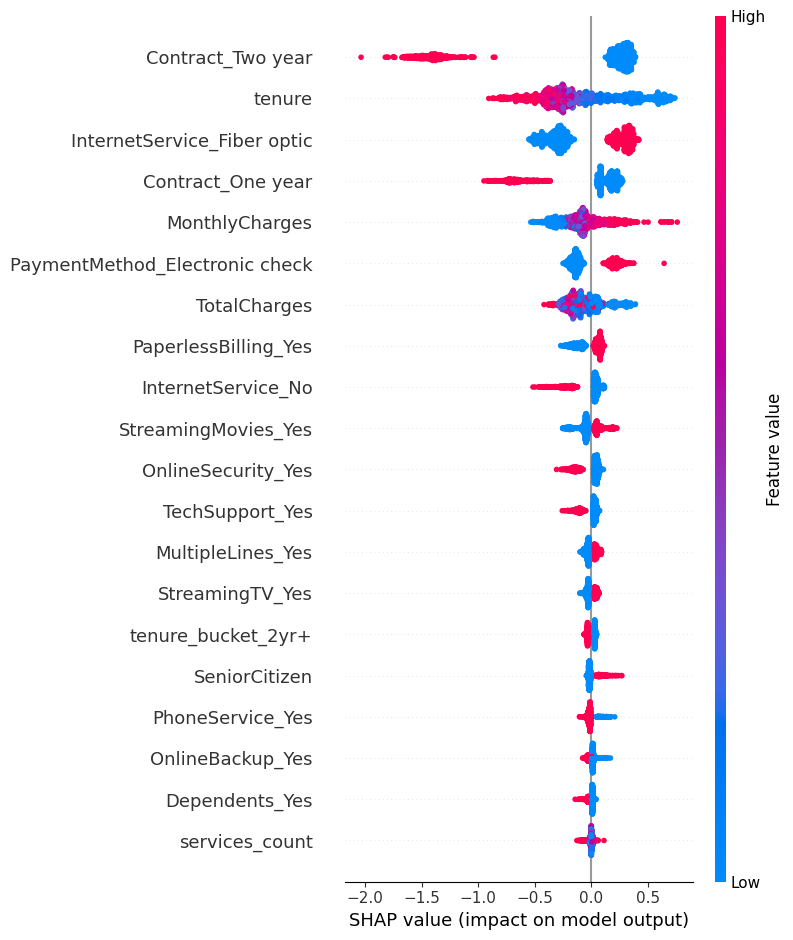

In [33]:
import shap

explainer = shap.TreeExplainer(best_xgb)
shap_values = explainer.shap_values(X_test)

# Global summary plot - shows top drivers overall
shap.summary_plot(shap_values, X_test)

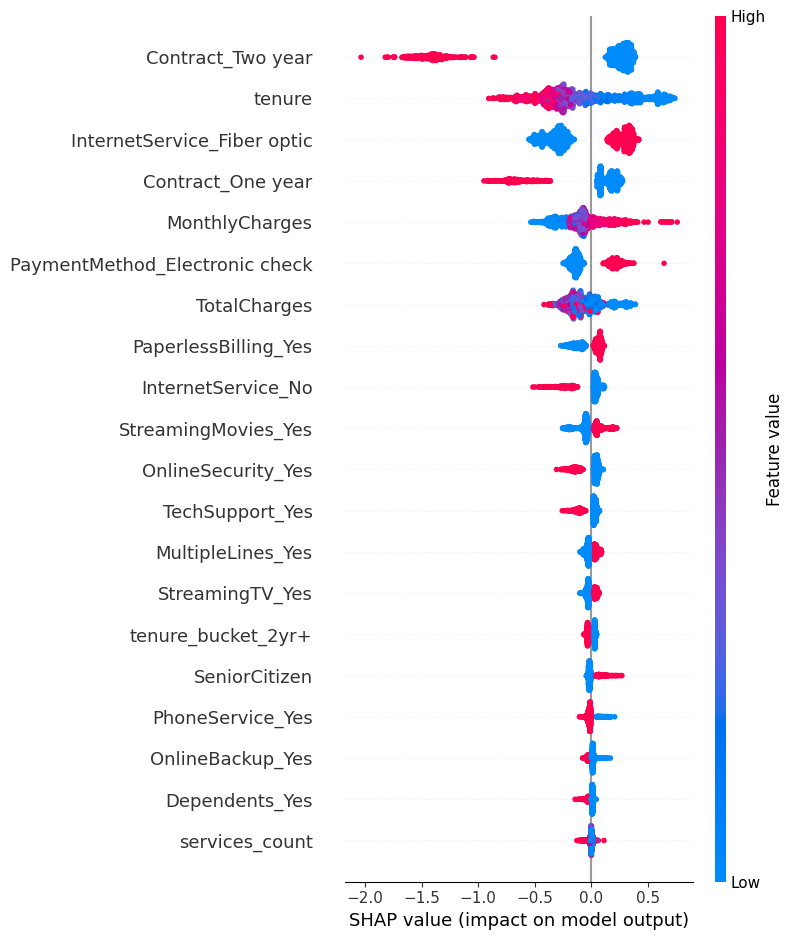

In [34]:
import shap

explainer = shap.TreeExplainer(best_xgb)
shap_values = explainer.shap_values(X_test)
shap.summary_plot(shap_values, X_test)

In [35]:
import xgboost, shap
print("XGBoost:", xgboost.__version__)
print("SHAP:", shap.__version__)

XGBoost: 1.7.6
SHAP: 0.49.1


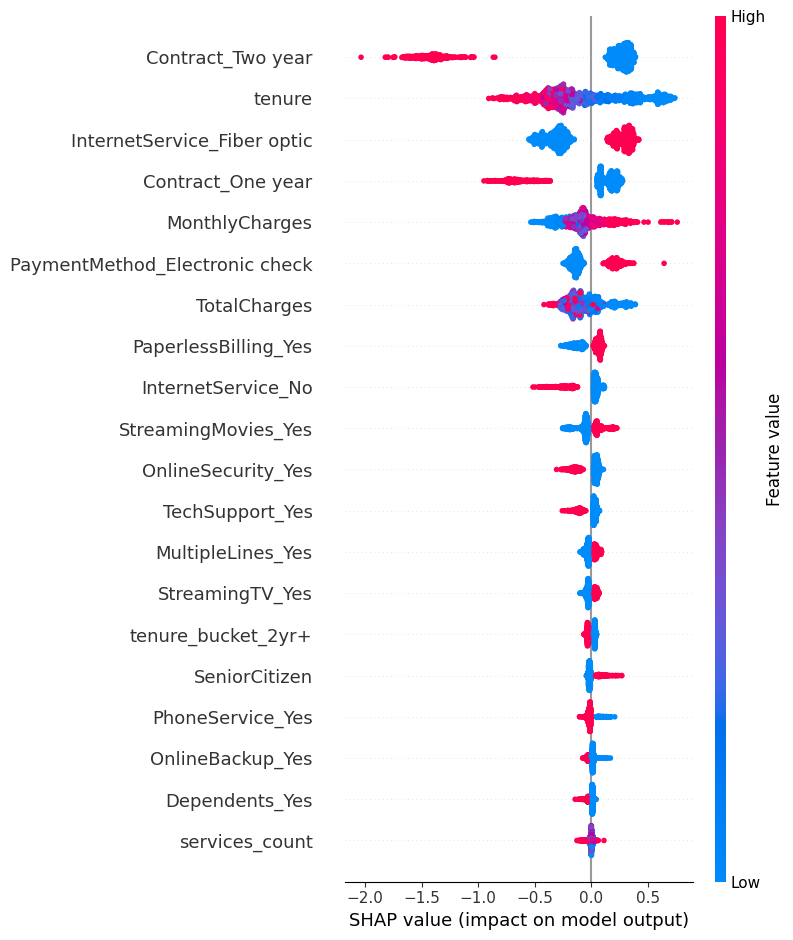

In [36]:
import shap

explainer = shap.TreeExplainer(best_xgb)
shap_values = explainer.shap_values(X_test)
shap.summary_plot(shap_values, X_test)

Customer index: 1090
Predicted churn probability: 0.923


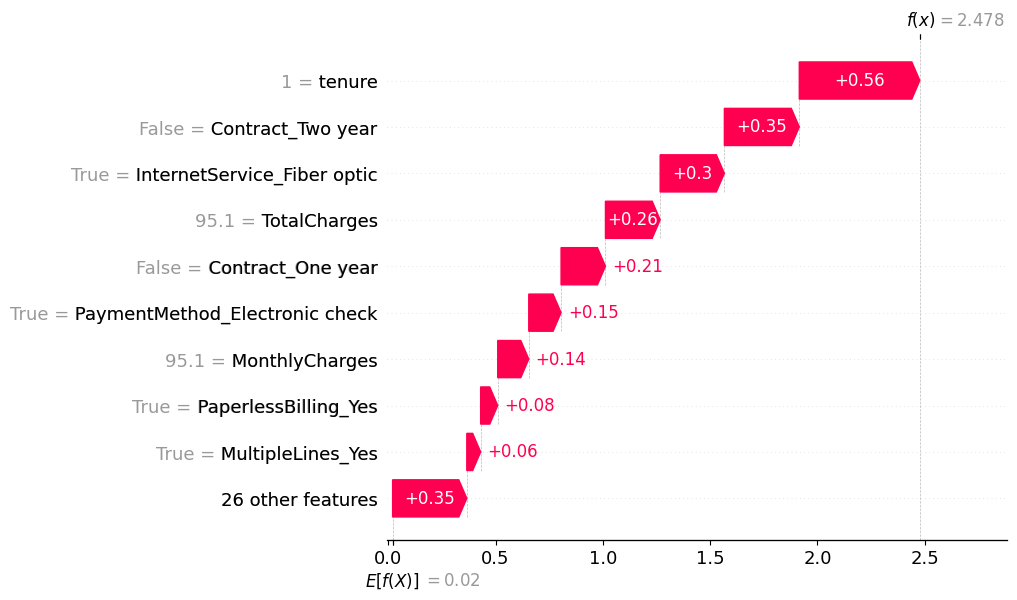

In [37]:
# Pick a high-risk customer (highest predicted churn probability in test set)
import numpy as np

high_risk_idx = np.argmax(y_proba_best)
print(f"Customer index: {high_risk_idx}")
print(f"Predicted churn probability: {y_proba_best[high_risk_idx]:.3f}")

# Waterfall plot for this customer
shap.plots.waterfall(shap.Explanation(
    values=shap_values[high_risk_idx],
    base_values=explainer.expected_value,
    data=X_test.iloc[high_risk_idx],
    feature_names=X_test.columns.tolist()
))

In [38]:
addon_cols = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 
              'TechSupport', 'StreamingTV', 'StreamingMovies']

# Average monthly charge uplift per service (rough estimate across the dataset)
service_avg_value = {}
for col in addon_cols:
    with_service = df[df[col] == 'Yes']['MonthlyCharges'].mean()
    without_service = df[df[col] == 'No']['MonthlyCharges'].mean()
    service_avg_value[col] = with_service - without_service

print(service_avg_value)

{'OnlineSecurity': np.float64(3.145664578443032), 'OnlineBackup': np.float64(11.143595422165674), 'DeviceProtection': np.float64(14.221204254484661), 'TechSupport': np.float64(6.09345400328958), 'StreamingTV': np.float64(23.349051253702342), 'StreamingMovies': np.float64(23.041566545575932)}


In [39]:
def calc_opportunity(row):
    missing_services = [col for col in addon_cols if row[col] == 'No']
    return sum(service_avg_value[col] for col in missing_services)

df['opportunity_value'] = df.apply(calc_opportunity, axis=1)
df[['customerID', 'opportunity_value']].head() if 'customerID' in df.columns else df['opportunity_value'].head()

0    69.850941
1    63.627667
2    66.705276
3    57.534213
4    80.994536
Name: opportunity_value, dtype: float64

In [40]:
# Re-prepare full X (same encoding as training)
X_full = df_encoded.drop(['Churn', 'Churn_binary'], axis=1)

# Predict churn probability for everyone
df['churn_probability'] = best_xgb.predict_proba(X_full)[:, 1]

In [41]:
df['tenure_normalized'] = df['tenure'] / df['tenure'].max()

In [42]:
# Weighted formula: lower churn risk + higher tenure + higher adoption = healthier customer
df['health_score'] = (
    0.5 * (1 - df['churn_probability']) +   # 50% weight: retention likelihood
    0.3 * df['tenure_normalized'] +          # 30% weight: loyalty/tenure
    0.2 * df['adoption_score']               # 20% weight: service adoption
) * 100

df[['churn_probability', 'tenure_normalized', 'adoption_score', 'health_score']].head()

,churn_probability,tenure_normalized,adoption_score,health_score
0,0.802225,0.013889,0.166667,13.638726
1,0.121183,0.472222,0.333333,64.774187
2,0.661669,0.027778,0.333333,24.416570
3,0.125668,0.625000,0.500000,72.466589
4,0.816978,0.027778,0.000000,9.984434


In [43]:
def risk_tier(prob):
    if prob >= 0.6:
        return 'High Risk'
    elif prob >= 0.3:
        return 'Medium Risk'
    else:
        return 'Low Risk'

df['risk_tier'] = df['churn_probability'].apply(risk_tier)
df['risk_tier'].value_counts()

risk_tier
Low Risk       3030
High Risk      2209
Medium Risk    1804
Name: count, dtype: int64

In [44]:
df['risk_tier'].value_counts()


risk_tier
Low Risk       3030
High Risk      2209
Medium Risk    1804
Name: count, dtype: int64

In [45]:
# Re-attach customerID for the final output (you saved it earlier as customer_ids)
df['customerID'] = customer_ids.values

final_output = df[[
    'customerID', 'churn_probability', 'risk_tier', 
    'tenure', 'adoption_score', 'opportunity_value', 
    'health_score', 'Contract', 'InternetService', 
    'PaymentMethod', 'MonthlyCharges', 'TotalCharges'
]].copy()

final_output.head(10)

,customerID,churn_probability,risk_tier,tenure,adoption_score,opportunity_value,health_score,Contract,InternetService,PaymentMethod,MonthlyCharges,TotalCharges
0,7590-VHVEG,0.802225,High Risk,1,0.166667,69.850941,13.638726,Month-to-month,DSL,Electronic check,29.85,29.85
1,5575-GNVDE,0.121183,Low Risk,34,0.333333,63.627667,64.774187,One year,DSL,Mailed check,56.95,1889.50
2,3668-QPYBK,0.661669,High Risk,2,0.333333,66.705276,24.416570,Month-to-month,DSL,Mailed check,53.85,108.15
3,7795-CFOCW,0.125668,Low Risk,45,0.500000,57.534213,72.466589,One year,DSL,Bank transfer (automatic),42.30,1840.75
4,9237-HQITU,0.816978,High Risk,2,0.000000,80.994536,9.984434,Month-to-month,Fiber optic,Electronic check,70.70,151.65
5,9305-CDSKC,0.886727,High Risk,8,0.500000,20.382714,18.996976,Month-to-month,Fiber optic,Electronic check,99.65,820.50
6,1452-KIOVK,0.640554,High Risk,22,0.333333,46.501889,33.805639,Month-to-month,Fiber optic,Credit card (automatic),89.10,1949.40
7,6713-OKOMC,0.403217,Medium Risk,10,0.166667,77.848871,37.339146,Month-to-month,DSL,Mailed check,29.75,301.90
8,7892-POOKP,0.759684,High Risk,28,0.666667,14.289260,37.015796,Month-to-month,Fiber optic,Electronic check,104.80,3046.05
9,6388-TABGU,0.097194,Low Risk,62,0.333333,66.705276,77.640320,One year,DSL,Bank transfer (automatic),56.15,3487.95


In [46]:
final_output.to_csv('../outputs/customer_scored_output.csv', index=False)
print("Exported successfully")
print(final_output.shape)

Exported successfully
(7043, 12)
